In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Ton dataset
from src.pannuke_dataset import PannukePreparedDataset

# Ajuste
DATA_ROOT = Path(r"C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\data\prepared\pannuke")
SPLIT = "train"
IDX = 0

N_RAYS_EXPECTED = 64
N_NUCLEUS_CLASSES = 5


In [11]:
def show(img, title="", cmap=None):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

def random_colors(n, seed=0):
    rng = np.random.default_rng(seed)
    return rng.random((n, 3))

def colorize_instances(inst, seed=0):
    inst = inst.astype(np.int32)
    K = int(inst.max())
    colors = random_colors(K + 1, seed=seed)
    colors[0] = 0  # background noir
    out = colors[inst]
    return out

def boundaries_from_inst(inst):
    # boundary simple sans skimage: pixels dont un voisin a un id différent
    inst = inst.astype(np.int32)
    H, W = inst.shape
    b = np.zeros((H, W), dtype=bool)
    b[:, 1:] |= (inst[:, 1:] != inst[:, :-1])
    b[:, :-1] |= (inst[:, :-1] != inst[:, 1:])
    b[1:, :] |= (inst[1:, :] != inst[:-1, :])
    b[:-1, :] |= (inst[:-1, :] != inst[1:, :])
    return b

def overlay_boundaries(img_rgb, inst, color=(1,0,0)):
    img_rgb = np.clip(img_rgb, 0, 1).copy()
    b = boundaries_from_inst(inst)
    img_rgb[b] = np.array(color, dtype=np.float32)
    return img_rgb

def summarize_mask(mask):
    mask = mask.astype(np.int32)
    ids = np.unique(mask)
    ids_fg = ids[ids != 0]
    areas = []
    if ids_fg.size > 0:
        for i in ids_fg:
            areas.append(int((mask == i).sum()))
    return {
        "H": mask.shape[0],
        "W": mask.shape[1],
        "n_instances": int(ids_fg.size),
        "min_area": int(np.min(areas)) if areas else 0,
        "median_area": int(np.median(areas)) if areas else 0,
        "max_area": int(np.max(areas)) if areas else 0,
    }


Name: img_000001.npy
Image: (256, 256, 3) float32 range: 0.10980392247438431 1.0
Mask : (256, 256) int32 ids: (0, 7)
Types: (256, 256) int32 ids: (0, 3)
Mask summary: {'H': 256, 'W': 256, 'n_instances': 7, 'min_area': 354, 'median_area': 588, 'max_area': 2955}


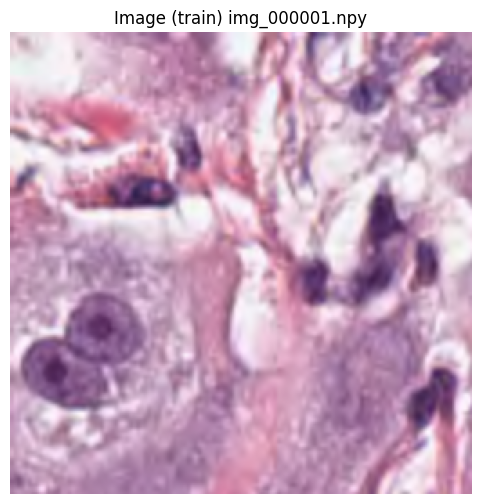

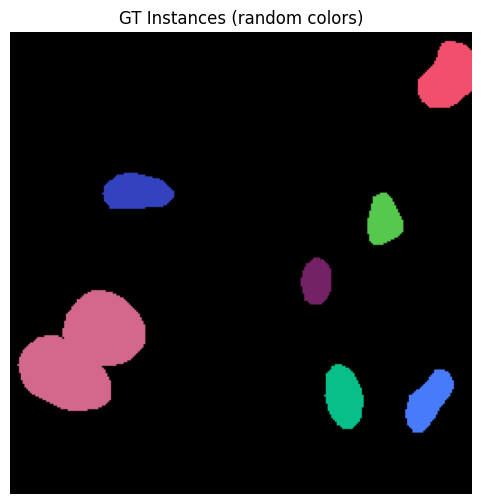

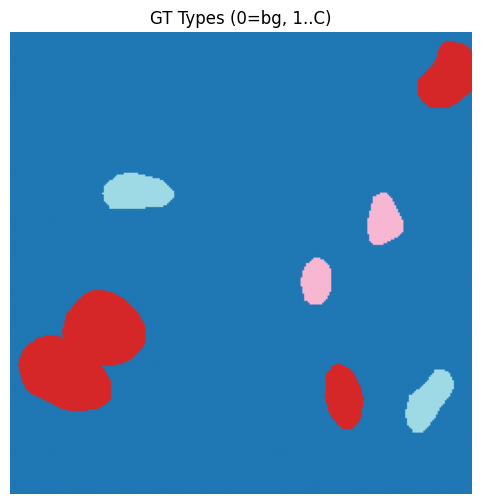

In [12]:
ds_raw = PannukePreparedDataset(
    root=DATA_ROOT,
    split=SPLIT,
    transform=None,
    return_image_name=True,
)

img_t, mask_t, types_t, name = ds_raw[IDX]

img = img_t.permute(1,2,0).numpy()          # (H,W,3)
mask = mask_t.numpy().astype(np.int32)      # (H,W)
types = None if types_t is None else types_t.numpy().astype(np.int32)

print("Name:", name)
print("Image:", img.shape, img.dtype, "range:", float(img.min()), float(img.max()))
print("Mask :", mask.shape, mask.dtype, "ids:", (mask.min(), mask.max()))
if types is not None:
    print("Types:", types.shape, types.dtype, "ids:", (types.min(), types.max()))
else:
    print("Types: None")

print("Mask summary:", summarize_mask(mask))

# Affichages
show(np.clip(img,0,1), f"Image ({SPLIT}) {name}")
show(colorize_instances(mask, seed=1), "GT Instances (random colors)")
if types is not None:
    show(types, "GT Types (0=bg, 1..C)", cmap="tab20")


Dist path: dist_000001.npy
Dists shape: (64, 256, 256) dtype: float32
Dists stats: min 0.0 max 74.0 mean 1.613506555557251
Mean dist on BG pixels: 0.0
Non-zero ratio on FG (all rays pooled): 0.9564985795454546


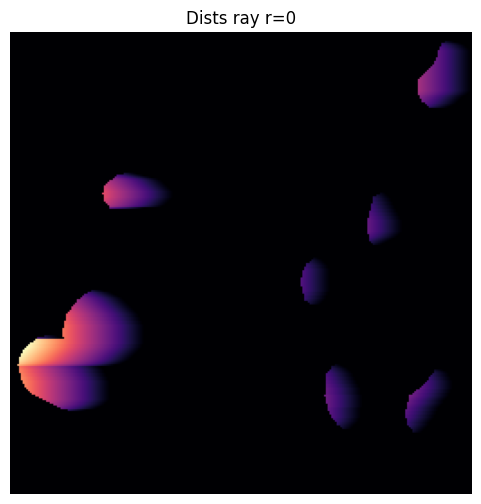

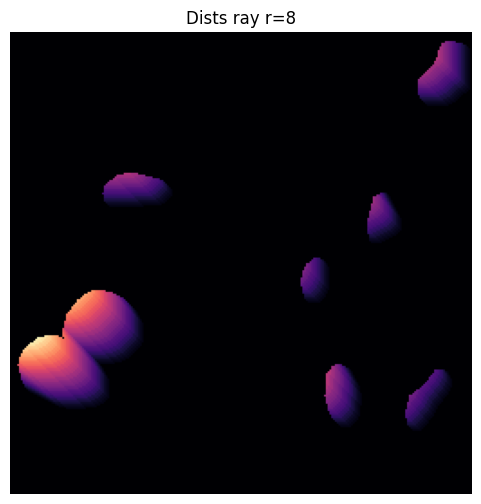

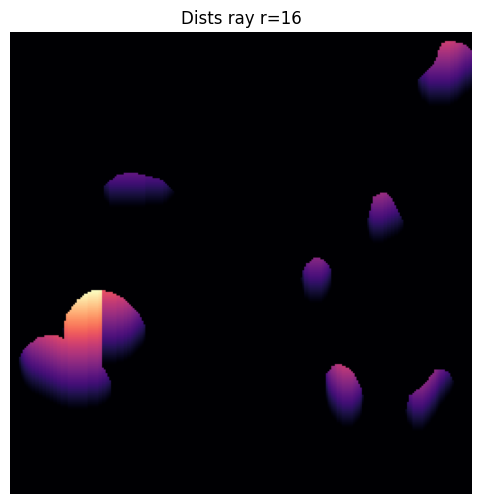

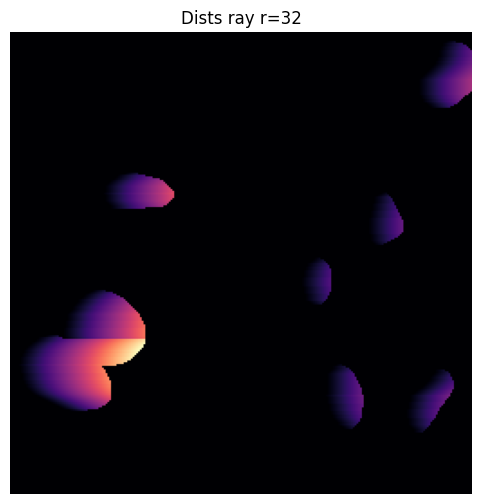

In [4]:
dist_path = DATA_ROOT / SPLIT / "targets_stardist" / name.replace("img_", "dist_")
assert dist_path.exists(), f"Missing dist file: {dist_path}"

dists = np.load(dist_path).astype(np.float32)  # (R,H,W)

print("Dist path:", dist_path.name)
print("Dists shape:", dists.shape, "dtype:", dists.dtype)
print("Dists stats:", "min", float(dists.min()), "max", float(dists.max()), "mean", float(dists.mean()))

# Checks essentiels
assert dists.ndim == 3, "dists must be (R,H,W)"
R, H2, W2 = dists.shape
assert (H2, W2) == mask.shape, f"dists spatial mismatch: {(H2,W2)} vs mask {mask.shape}"
assert R == N_RAYS_EXPECTED, f"RAYS mismatch: got {R}, expected {N_RAYS_EXPECTED}"

# Check logique: bg doit être ~0 partout
bg_mean = float(dists[:, mask == 0].mean()) if (mask == 0).any() else 0.0
print("Mean dist on BG pixels:", bg_mean)

# Check logique: sur fg, au moins un rayon non nul
fg = (mask > 0)
if fg.any():
    nonzero_ratio = float((dists[:, fg] > 0).mean())
    print("Non-zero ratio on FG (all rays pooled):", nonzero_ratio)

# Visualiser quelques rayons
for r in [0, R//8, R//4, R//2]:
    show(dists[r], f"Dists ray r={r}", cmap="magma")


Name: img_000001.npy
img_t2: (3, 256, 256) torch.float32
target keys: ['foreground', 'distances', 'classes']
foreground: (1, 256, 256) torch.float32 min/max 0.0 1.0
distances: (64, 256, 256) torch.float32 min/max 0.0 74.0
classes: (256, 256) int64 unique: [0 1 2 3] ... max 3


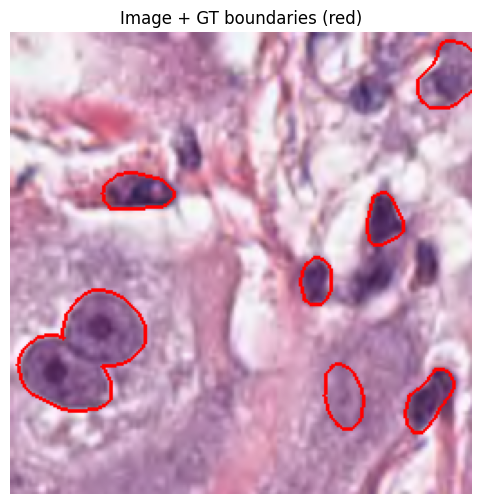

In [5]:
# on recrée un dataset avec ta logique load_dists=True + transform
from models.lit_stardist_pannuke import stardist_eval_transform  # si tu l'as dans un fichier, sinon recopie la fonction

ds_eval = PannukePreparedDataset(
    root=DATA_ROOT,
    split=SPLIT,
    transform=stardist_eval_transform,
    return_image_name=True,
    load_dists=True,
    n_rays=N_RAYS_EXPECTED,
)

img_t2, target, types_t2, name2 = ds_eval[IDX]

print("Name:", name2)
print("img_t2:", tuple(img_t2.shape), img_t2.dtype)
print("target keys:", list(target.keys()))
print("foreground:", tuple(target["foreground"].shape), target["foreground"].dtype, "min/max", float(target["foreground"].min()), float(target["foreground"].max()))
print("distances:", tuple(target["distances"].shape), target["distances"].dtype, "min/max", float(target["distances"].min()), float(target["distances"].max()))

if "classes" in target:
    cls = target["classes"].numpy()
    print("classes:", cls.shape, cls.dtype, "unique:", np.unique(cls)[:20], "...", "max", int(cls.max()))
    # classes paper-aligned: 0..C (bg included)
    assert cls.min() >= 0 and cls.max() <= N_NUCLEUS_CLASSES, "classes out of expected range 0..C"
else:
    print("classes: missing (types not provided)")

# viz overlay boundaries
img2 = img_t2.permute(1,2,0).numpy()
mask2 = ds_raw[IDX][1].numpy().astype(np.int32)
vis = overlay_boundaries(np.clip(img2,0,1), mask2, color=(1,0,0))
show(vis, "Image + GT boundaries (red)")


prob_logits: (1, 1, 256, 256)
dist_pos   : (1, 64, 256, 256)
class_logits: (1, 6, 256, 256)


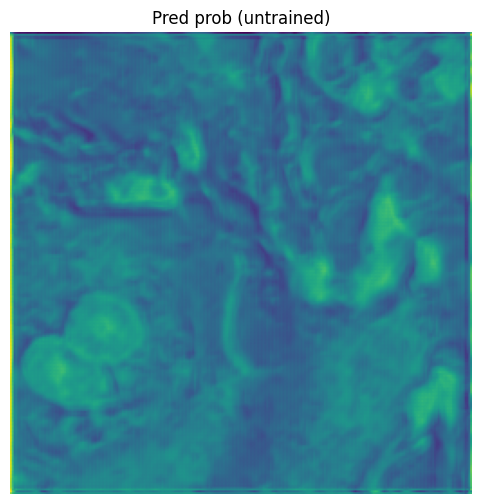

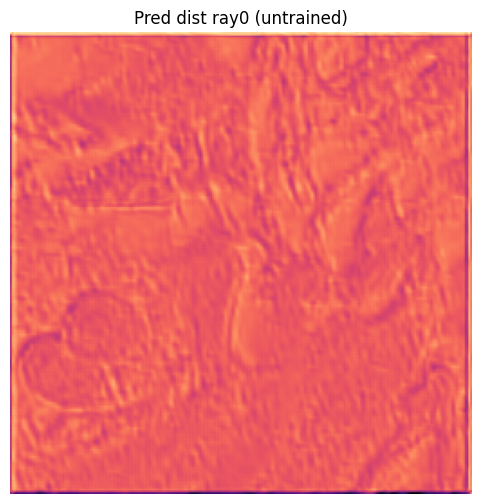

In [6]:
# Import ton modèle paper-aligned
try:
    from models.stardist import StarDistPaper as StarDistModel
except Exception:
    from models.stardist import StarDist as StarDistModel

device = "cuda" if torch.cuda.is_available() else "cpu"

model = StarDistModel(input_ch=3, n_rays=N_RAYS_EXPECTED, n_nucleus_classes=N_NUCLEUS_CLASSES, base_ch=32).to(device)
model.eval()

x = img_t2.unsqueeze(0).to(device)  # (1,3,H,W)
with torch.no_grad():
    prob_logits, dist_pos, class_logits = model(x)

print("prob_logits:", tuple(prob_logits.shape))
print("dist_pos   :", tuple(dist_pos.shape))
print("class_logits:", tuple(class_logits.shape))

# Checks
assert prob_logits.shape[1] == 1
assert dist_pos.shape[1] == N_RAYS_EXPECTED
assert class_logits.shape[1] == (N_NUCLEUS_CLASSES + 1), "class head should include background"

prob = torch.sigmoid(prob_logits)[0,0].detach().cpu().numpy()
show(prob, "Pred prob (untrained)", cmap="viridis")

# untrained dist peut être faible/hasardeux, mais on regarde juste la forme
d0 = dist_pos[0, 0].detach().cpu().numpy()
show(d0, "Pred dist ray0 (untrained)", cmap="magma")


Pred instances (untrained): 0


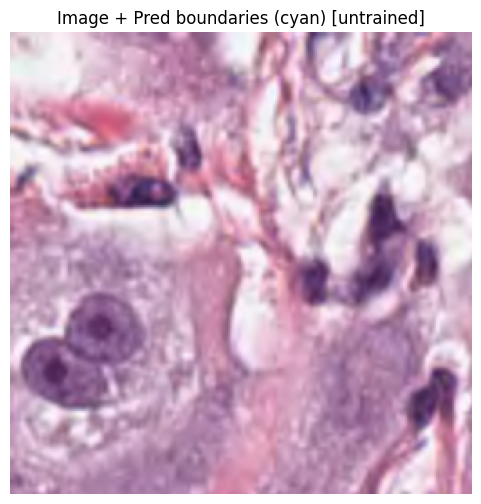

In [7]:
try:
    from models.stardist import stardist_decode_paper as decode_fn
except Exception:
    from models.stardist import stardist_decode as decode_fn

with torch.no_grad():
    prob_logits, dist_pos, class_logits = model(x)

prob_map = torch.sigmoid(prob_logits)[0,0].cpu().numpy().astype(np.float32)
dist_map = dist_pos[0].cpu().numpy().astype(np.float32)
cls_prob = torch.softmax(class_logits, dim=1)[0].cpu().numpy().astype(np.float32)

pred_inst, pred_cls = decode_fn(
    prob_map=prob_map,
    dist_map=dist_map,
    class_prob=cls_prob,
    prob_thr=0.5,
    nms_iou_thr=0.3,
    use_local_maxima=True,
    local_max_footprint=3,
    max_candidates=2000,
    min_area=10,
    vote_thr=0.5,
)

print("Pred instances (untrained):", int(pred_inst.max()))
vis_pred = overlay_boundaries(np.clip(img2,0,1), pred_inst.astype(np.int32), color=(0,1,1))
show(vis_pred, "Image + Pred boundaries (cyan) [untrained]")


In [13]:
from pathlib import Path
import numpy as np
from tqdm import tqdm

DATA_ROOT = Path(r"C:\Users\yehadji\Desktop\projects\ME\cell_segmentation\data\prepared\pannuke")
SPLIT = "train"
N_RAYS_EXPECTED = 64

img_dir = DATA_ROOT / SPLIT / "images"
dist_dir = DATA_ROOT / SPLIT / "targets_stardist"

img_files = sorted(img_dir.glob("img_*.npy"))
bad = []
for img_path in tqdm(img_files, desc=f"Verify dists [{SPLIT}]"):
    name = img_path.name
    dist_path = dist_dir / name.replace("img_", "dist_")
    if not dist_path.exists():
        bad.append((name, "missing"))
        continue
    try:
        d = np.load(dist_path, mmap_mode="r")
        if d.ndim != 3 or d.shape[0] != N_RAYS_EXPECTED:
            bad.append((name, f"shape={getattr(d,'shape',None)}"))
    except Exception as e:
        bad.append((name, f"read_error: {e}"))

print("Total images:", len(img_files))
print("Bad dist files:", len(bad))
if bad:
    print("First 10 issues:", bad[:10])


Verify dists [train]: 100%|██████████| 2620/2620 [00:05<00:00, 464.26it/s]

Total images: 2620
Bad dist files: 0


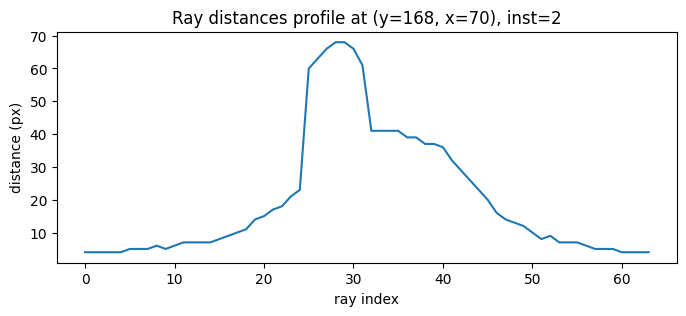

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# prend un pixel foreground "au hasard"
ys, xs = np.where(mask > 0)
i = len(ys)//2
y0, x0 = int(ys[i]), int(xs[i])

profile = dists[:, y0, x0]
plt.figure(figsize=(8,3))
plt.plot(profile)
plt.title(f"Ray distances profile at (y={y0}, x={x0}), inst={mask[y0,x0]}")
plt.xlabel("ray index")
plt.ylabel("distance (px)")
plt.show()
